# 03 — Train/Test Distribution Shift

**Amaç:** Numeric ve kategorik dağılım farklarını, unseen category riskini belirlemek.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from kaggle_s6_e7.config import (FIGURES_DIR, TABLES_DIR, TARGET_COL, ID_COL,
    PLOT_SAMPLE_SIZE, RANDOM_STATE, ensure_report_dirs)
from kaggle_s6_e7.data import load_competition_data, infer_feature_columns, validate_schema
ensure_report_dirs()
train, test = load_competition_data()
validate_schema(train, test)
cat_cols, num_cols = infer_feature_columns(train)
plot_df = train.sample(min(PLOT_SAMPLE_SIZE, len(train)), random_state=RANDOM_STATE)
sns.set_theme(style="whitegrid")

## Numeric shift özeti

In [2]:
from kaggle_s6_e7.eda import numeric_shift_summary, categorical_shift_summary
numeric_shift=numeric_shift_summary(train,test,num_cols)
display(numeric_shift)
numeric_shift.to_csv(TABLES_DIR / "03_numeric_shift.csv")
# Büyük örneklemde p-value yerine etki büyüklüğü olarak KS statistic önceliklidir.

,train_mean,test_mean,train_median,test_median,train_std,test_std,ks_statistic,ks_pvalue
feature,,,,,,,,
water_intake,2.188542,2.191508,2.17,2.18,0.518489,0.518771,0.003355,0.025299
step_count,8615.953050,8626.630524,8856.00,8857.00,3929.399831,3924.646677,0.002347,0.213390
heart_rate,75.096504,75.079560,75.10,75.10,8.175106,8.115118,0.001999,0.386290
sleep_duration,6.992597,6.993517,6.99,6.99,1.215407,1.216369,0.001791,0.594842
calorie_expenditure,2226.084931,2225.514941,2241.00,2240.00,347.532098,347.816761,0.001680,0.652375
exercise_duration,38.751456,38.796712,39.40,39.40,14.742189,14.711180,0.001648,0.633504
bmi,22.984925,22.984661,22.99,22.99,2.481787,2.478708,0.001125,0.959105


## Numeric percentile karşılaştırması

In [3]:
percentiles=[.001,.01,.05,.5,.95,.99,.999]
rows=[]
for col in num_cols:
    for source,df in [("train",train),("test",test)]:
        record={"feature":col,"source":source}
        record.update({f"q{q:g}":df[col].quantile(q) for q in percentiles})
        rows.append(record)
percentile_table=pd.DataFrame(rows)
display(percentile_table)
percentile_table.to_csv(TABLES_DIR / "03_numeric_percentiles.csv",index=False)

,feature,source,q0.001,q0.01,q0.05,q0.5,q0.95,q0.99,q0.999
0,sleep_duration,train,3.14000,4.19,4.95,6.99,9.05,9.92,9.99
1,sleep_duration,test,3.14181,4.18,4.95,6.99,9.05,9.92,9.99
2,heart_rate,train,50.50000,56.30,61.80,75.10,88.60,93.70,98.30
3,heart_rate,test,50.70000,56.70,61.90,75.10,88.50,93.50,98.10
4,bmi,train,16.06000,17.15,18.87,22.99,27.08,28.84,30.83
5,bmi,test,16.04000,17.18,18.88,22.99,27.08,28.84,30.83
6,calorie_expenditure,train,1213.00000,1404.00,1626.00,2241.00,2781.00,2979.00,3249.00
7,calorie_expenditure,test,1212.00000,1406.00,1625.00,2240.00,2782.00,2982.00,3255.70
8,step_count,train,1046.00000,1211.00,1769.00,8856.00,14253.00,14762.00,14991.00
9,step_count,test,1045.00000,1224.00,1784.00,8857.00,14259.00,14767.00,14991.00


## Kategorik shift ve unseen category

In [4]:
categorical_shift=categorical_shift_summary(train,test,cat_cols)
display(categorical_shift)
categorical_shift.to_csv(TABLES_DIR / "03_categorical_shift.csv")
for col in cat_cols:
    freq=pd.concat([train[col].value_counts(normalize=True,dropna=False).rename("train"),
                    test[col].value_counts(normalize=True,dropna=False).rename("test")],axis=1).fillna(0)
    print(f"\n{col}"); display(freq)

,total_variation_distance,train_unique,test_unique,test_only_categories
feature,,,,
gender,0.033092,4,4,[]
physical_activity_level,0.008563,4,4,[]
smoking_alcohol,0.002043,4,4,[]
sleep_quality,0.001330,4,4,[]
stress_level,0.001215,4,4,[]
diet_type,0.000826,4,4,[]



diet_type


,train,test
diet_type,,
veg,0.335366,0.334975
balanced,0.328781,0.329606
non-veg,0.325853,0.325417
NaN,0.010000,0.010002



stress_level


,train,test
stress_level,,
medium,0.379399,0.380615
high,0.257576,0.256390
low,0.243024,0.242997
NaN,0.120001,0.119999


...

,train,test
physical_activity_level,,
moderate,0.320308,0.322864
sedentary,0.318487,0.324494
active,0.308138,0.299574
NaN,0.053067,0.053068



smoking_alcohol


,train,test
smoking_alcohol,,
yes,0.324205,0.322164
no,0.318497,0.319787
occasional,0.315880,0.316632
NaN,0.041418,0.041416



gender


,train,test
gender,,
male,0.344530,0.346353
female,0.324619,0.291527
other,0.299879,0.331148
NaN,0.030971,0.030972


## Örneklemli görsel kontrol

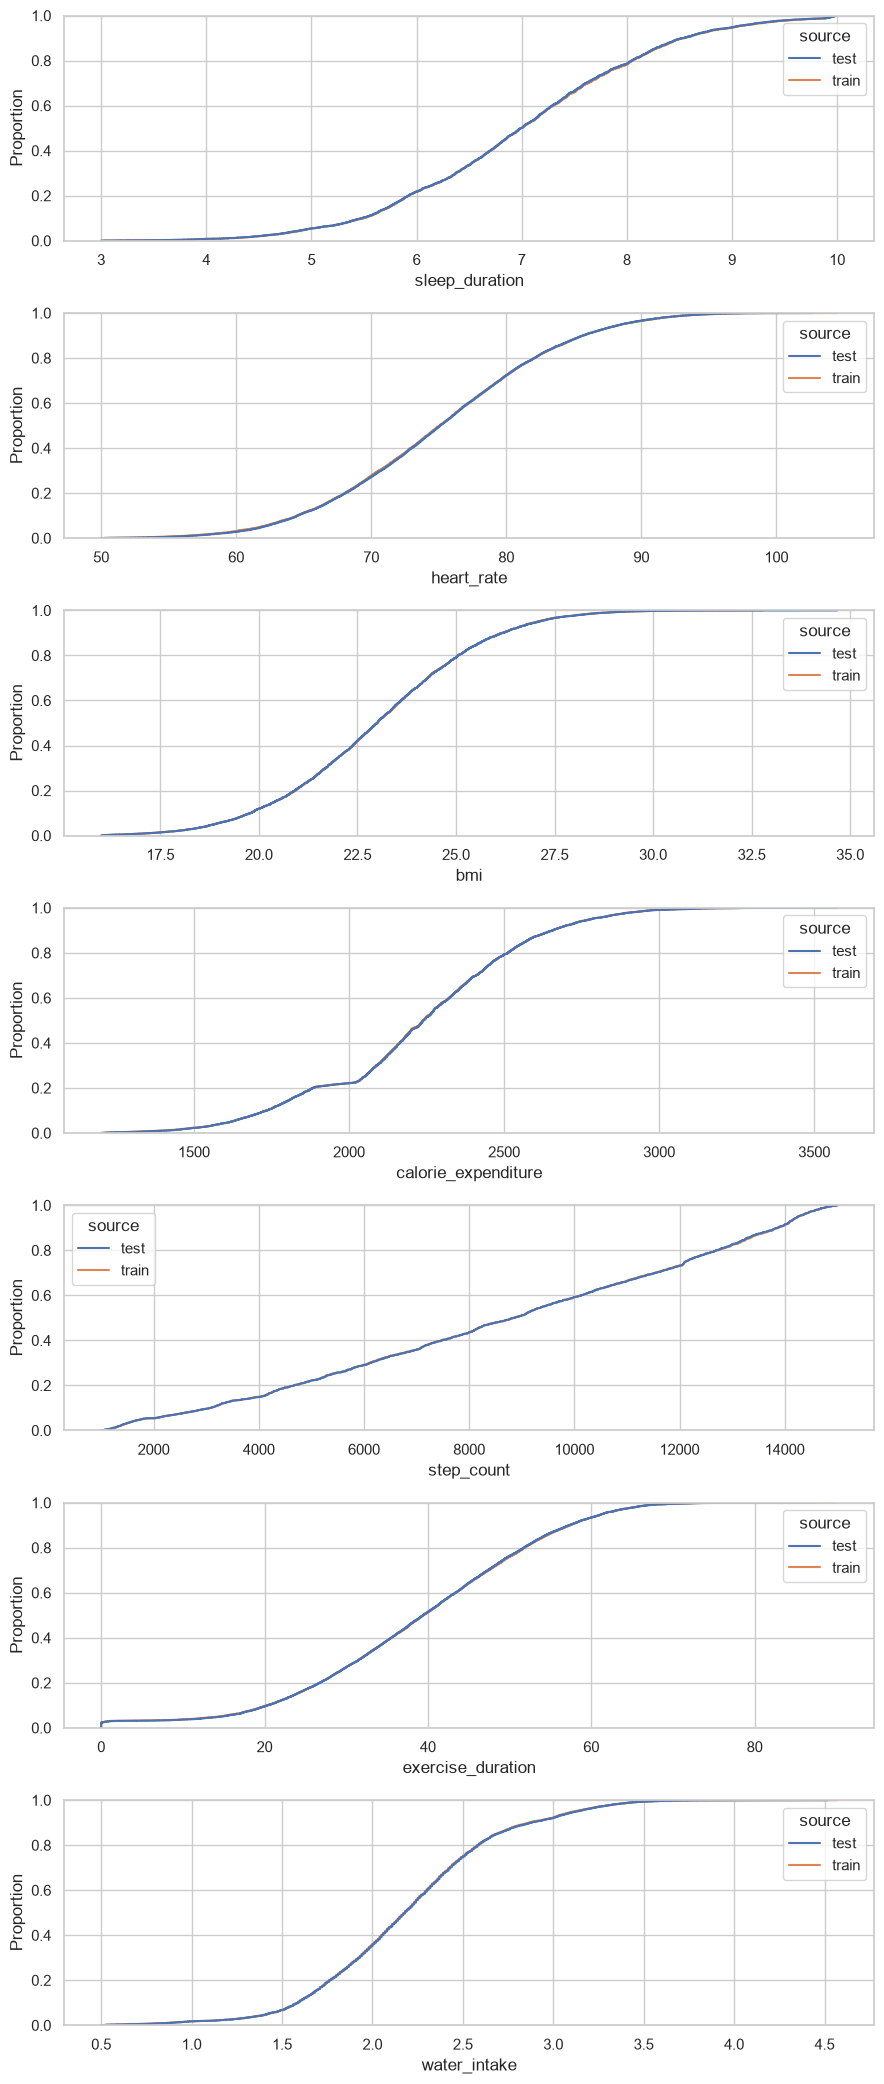

In [5]:
combined=pd.concat([train.assign(source="train"),test.assign(source="test")],ignore_index=True)
plot_combined=combined.groupby("source",group_keys=False).sample(n=min(50000,len(test)),random_state=RANDOM_STATE)
fig,axes=plt.subplots(len(num_cols),1,figsize=(9,3*len(num_cols)))
for col,ax in zip(num_cols,axes):
    sns.ecdfplot(data=plot_combined,x=col,hue="source",ax=ax)
fig.tight_layout(); fig.savefig(FIGURES_DIR / "03_numeric_shift_ecdf.png",dpi=150); plt.show()

## Karar notu
KS p-value büyük örneklem nedeniyle aşırı hassastır; karar için KS statistic, quantile farkı ve görseller birlikte değerlendirilir.